<a href="https://colab.research.google.com/github/srinivas340/ml_practice/blob/main/gold_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install kagglehub

In [4]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("altruistdelhite04/gold-price-data")
print("Path to dataset files:", path)

100%|██████████| 41.9k/41.9k [00:00<00:00, 26.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altruistdelhite04/gold-price-data/versions/1


In [5]:
files = os.listdir(path)
print("Files available:", files)
csv_file_path = f"{path}/{files[0]}"
df = pd.read_csv(csv_file_path)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

Files available: ['gld_price_data.csv']


In [6]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


In [7]:
df.shape

(2290, 6)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [9]:
df.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [10]:
df.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371008,1654.315776,122.732875,31.842221,20.084997,1.283653
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547


<Axes: >

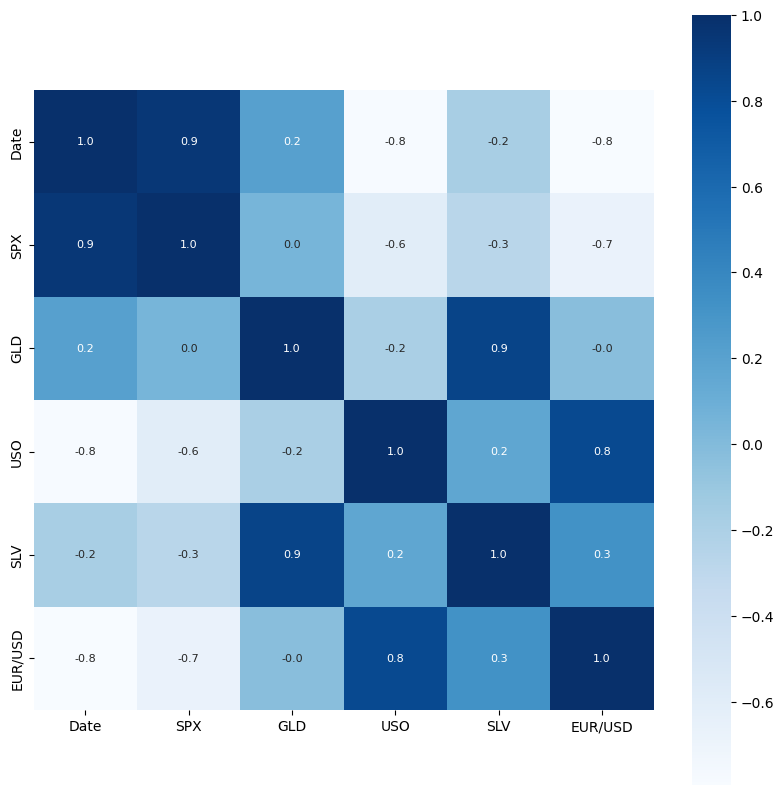

In [12]:
#correlation
correlation=df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [13]:
print(correlation['EUR/USD'])

Date      -0.794540
SPX       -0.672017
GLD       -0.024375
USO        0.829317
SLV        0.321631
EUR/USD    1.000000
Name: EUR/USD, dtype: float64


In [15]:
print(correlation['GLD'])

Date       0.209118
SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<Axes: xlabel='GLD', ylabel='Density'>

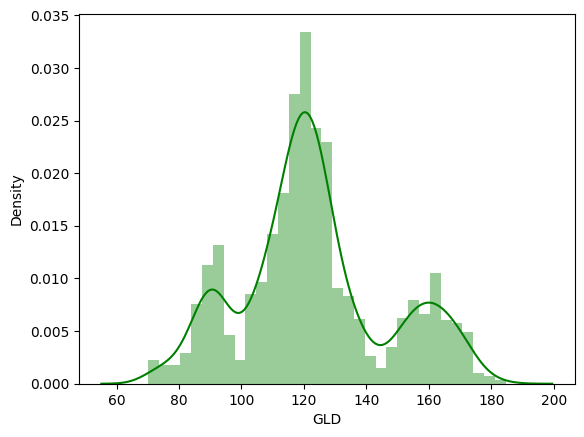

In [17]:
# checking the distribution of the GLD Price
sns.distplot(df['GLD'],color='green')

In [19]:
X=df.drop(['Date','GLD'],axis=1)
Y=df['GLD']

In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [21]:
model=RandomForestRegressor()

In [22]:
model.fit(X_train,Y_train)

RandomForestRegressor()

In [23]:
from sklearn import metrics
#Predict on the test data
test_data_prediction = model.predict(X_test)
#Evaluate performance
r2_score = metrics.r2_score(Y_test, test_data_prediction)
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
mse = metrics.mean_squared_error(Y_test, test_data_prediction)
rmse = np.sqrt(mse)
print(f"R Squared Error: {r2_score:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

R Squared Error: 0.9889
Mean Absolute Error: 1.3375
Root Mean Squared Error: 2.4251


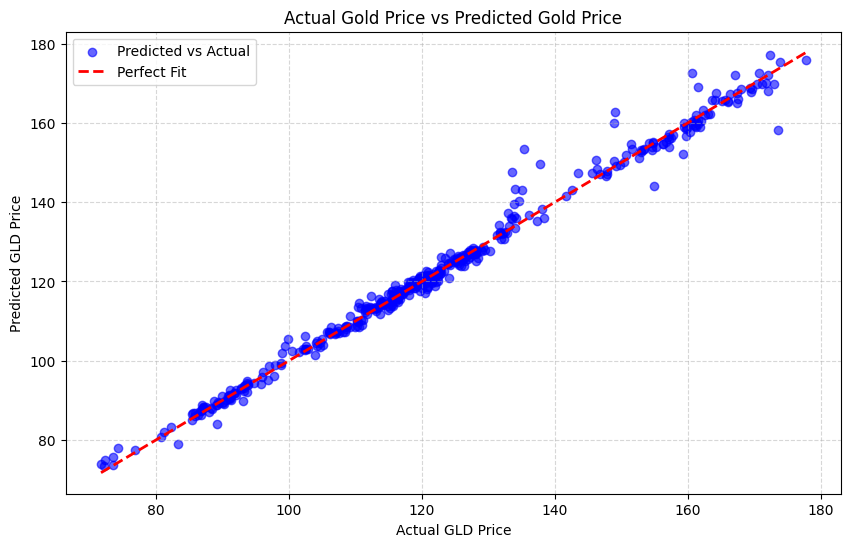

In [24]:
#Visualization: Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, test_data_prediction, color='blue', alpha=0.6, label='Predicted vs Actual')

# Plotting the perfect prediction line
max_val = max(Y_test.max(), test_data_prediction.max())
min_val = min(Y_test.min(), test_data_prediction.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('Actual GLD Price')
plt.ylabel('Predicted GLD Price')
plt.title('Actual Gold Price vs Predicted Gold Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

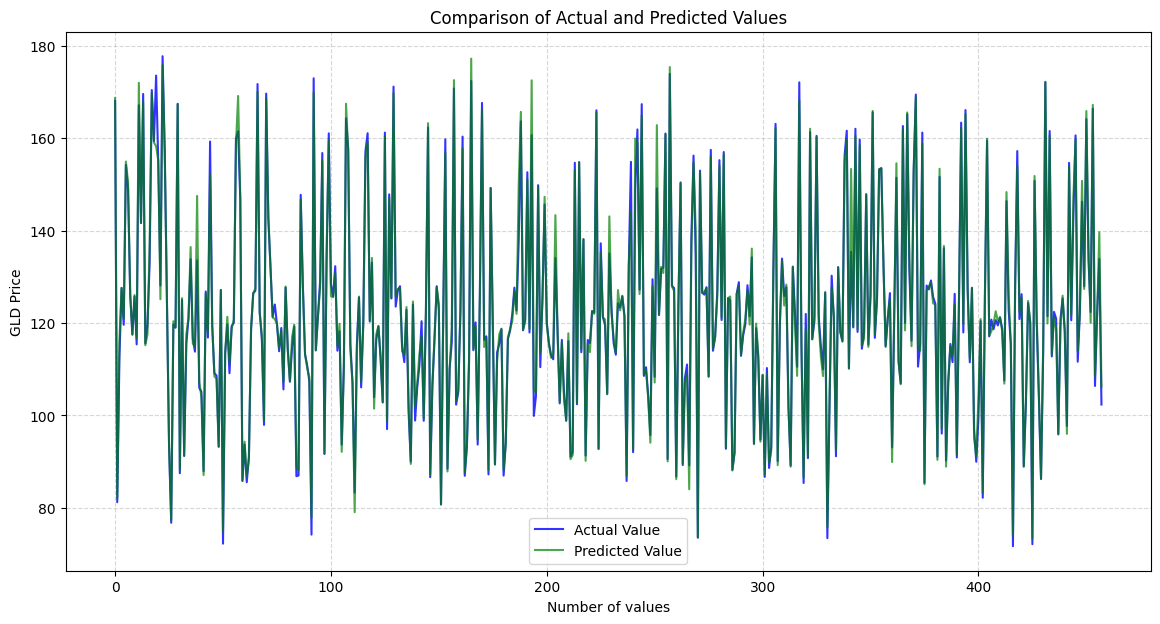

In [25]:
# Visualization: Comparison Plot (Line Plot)
# Convert Y_test to list to align index for plotting
Y_test_list = list(Y_test)

plt.figure(figsize=(14, 7))
plt.plot(Y_test_list, color='blue', label='Actual Value', alpha=0.8)
plt.plot(test_data_prediction, color='green', label='Predicted Value', alpha=0.7)
plt.title('Comparison of Actual and Predicted Values')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()